# 06 · Evaluación — Importancia de variables (XGBoost tuneado)

¿Qué variables sostienen las predicciones del modelo? Cruzamos **dos lentes
complementarias**, porque ninguna es suficiente por sí sola:

## 1. Importancia nativa de XGBoost (basada en la estructura de los árboles)

XGBoost ofrece tres definiciones, calculadas sobre cómo se usaron las variables al
construir los árboles:

- **`gain`** (la de `feature_importances_`): mejora promedio en la función de
  pérdida que aporta cada *split* sobre esa variable. Es la más informativa de las
  tres — mide *cuánto ayuda a separar*.
- **`weight`** (frecuencia): cuántas veces se usó la variable para partir. Sesgada
  hacia variables continuas / de alta cardinalidad (ofrecen más puntos de corte).
- **`cover`**: nº promedio de observaciones afectadas por los splits de la variable.

**Limitación**: son importancias *del entrenamiento*, no de la generalización, y se
reparten de forma arbitraria entre variables correlacionadas (y aquí hay mucha
correlación entre las ventanas RFM u3/u6/u12).

## 2. Importancia por permutación (basada en el rendimiento fuera de muestra)

Se mide sobre el **test OOT**: se baraja aleatoriamente una variable y se observa
**cuánto cae el AUC**. Si romper la variable degrada el modelo, la variable
aportaba señal *que generaliza*. Es model-agnostic y honesta respecto a producción.

**Limitación**: ante dos variables muy correlacionadas, permutar una sola apenas
mueve el AUC (la otra la sustituye) → puede *subestimar* a ambas. Por eso la leemos
junto a la nativa, no en su lugar.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent

df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
X_test, y_test = X[test_mask], y[test_mask]

# --- cargar el modelo tuneado (o reconstruirlo desde los hiperparámetros) ---
model_path = base / "models" / "xgboost_tuned.joblib"
params_path = base / "05_modelling" / "xgboost_best_params.json"
if model_path.exists():
    model = joblib.load(model_path)
    print(f"modelo cargado: {model_path.relative_to(base)}")
else:
    if not params_path.exists():
        raise FileNotFoundError(
            "Falta el modelo. Corre primero 05_modelling/02_tuning_xgboost_optuna.ipynb "
            "(secciones 2 y 6) para generar models/xgboost_tuned.joblib.")
    best = json.load(open(params_path))["best_params"]
    spw = (y[train_mask] == 0).sum() / (y[train_mask] == 1).sum()
    model = XGBClassifier(**best, scale_pos_weight=spw, eval_metric="logloss",
                          tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X[train_mask], y[train_mask])
    print("modelo reconstruido desde hiperparámetros y entrenado en train OOT")

# El modelo está entrenado sobre el train OOT → lo explicamos/evaluamos sobre el
# test OOT (fuera de muestra). Para el modelo desplegado se reentrenaría con todo.
p_test = model.predict_proba(X_test)[:, 1]
print(f"test OOT: {test_mask.sum():,} filas | prevalencia churn {y_test.mean():.3f}")

modelo cargado: models/xgboost_tuned.joblib
test OOT: 803 filas | prevalencia churn 0.262


## A · Importancia nativa: gain, weight, cover

In [2]:
booster = model.get_booster()
imp = pd.DataFrame(index=FEATS)
for tipo in ["gain", "weight", "cover"]:
    s = booster.get_score(importance_type=tipo)          # dict; omite features sin splits
    imp[tipo] = pd.Series(s).reindex(FEATS).fillna(0.0)
imp["gain_norm"] = imp["gain"] / imp["gain"].sum()
imp = imp.sort_values("gain", ascending=False)
print("Top 15 por gain:")
print(imp.head(15).round(4).to_string())

Top 15 por gain:
                               gain  weight      cover  gain_norm
n_prod_u12                 388.7932   207.0  4882.8130     0.1672
monto_u6                   283.2166   210.0  3960.5486     0.1218
n_ped_u6                   268.9925    95.0  5224.9126     0.1157
n_ped_u12                  221.7453   197.0  4256.9780     0.0954
n_ped_u3                    90.5165   125.0  3690.6353     0.0389
monto_u3                    83.9233   360.0  3093.1116     0.0361
n_ped_acum                  69.3135   259.0  3166.6851     0.0298
n_prod_acum                 59.1784   142.0  1825.9259     0.0255
compras_hist                43.4150   331.0  3270.8638     0.0187
intensidad_u3               34.7954   116.0  3521.2188     0.0150
meses_activos_u12           30.2702   133.0  4160.9189     0.0130
meses_desde_compra_previa   28.9385   122.0  4477.8647     0.0124
monto_mean_u12              25.6915   178.0  2724.7915     0.0110
meses_activos_u3            23.2194     4.0   575.6833     

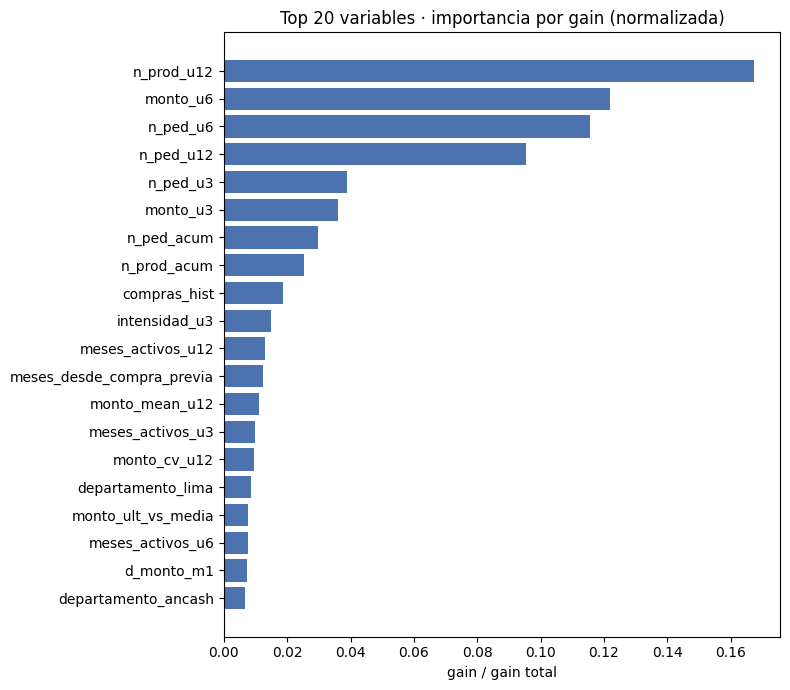

In [3]:
top = imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top["gain_norm"], color="#4c72b0")
ax.set_title("Top 20 variables · importancia por gain (normalizada)")
ax.set_xlabel("gain / gain total")
plt.tight_layout(); plt.show()

## B · Importancia por permutación (sobre el test OOT)

`n_repeats=20` para tener una media y una desviación estándar por variable. La
métrica es `roc_auc`: la caída de AUC al barajar la variable.

In [4]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model, X_test, y_test, scoring="roc_auc",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = (pd.DataFrame({"caida_auc_mean": perm.importances_mean,
                         "caida_auc_std": perm.importances_std}, index=FEATS)
           .sort_values("caida_auc_mean", ascending=False))
print("Top 15 por importancia de permutación (caída de AUC):")
print(perm_df.head(15).round(5).to_string())

Top 15 por importancia de permutación (caída de AUC):
                           caida_auc_mean  caida_auc_std
n_prod_u12                        0.00972        0.00321
n_ped_u12                         0.00952        0.00434
n_ped_u3                          0.00257        0.00119
n_ped_u6                          0.00243        0.00207
compras_hist                      0.00181        0.00466
intensidad_u3                     0.00153        0.00086
meses_desde_compra_previa         0.00138        0.00115
monto_u6                          0.00111        0.00321
n_ped_acum                        0.00110        0.00345
departamento_la libertad          0.00088        0.00066
ticket_prom_u3                    0.00085        0.00048
monto_cv_u12                      0.00077        0.00154
departamento_lima                 0.00077        0.00028
meses_activos_u12                 0.00076        0.00115
d_nped_m1                         0.00050        0.00068


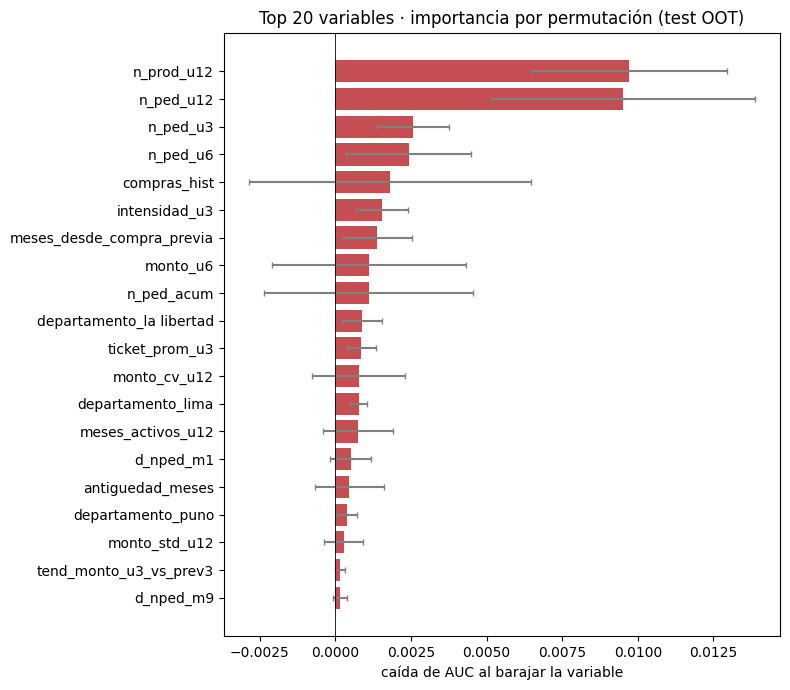

In [5]:
top_p = perm_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_p.index, top_p["caida_auc_mean"], xerr=top_p["caida_auc_std"],
        color="#c44e52", ecolor="gray", capsize=2)
ax.set_title("Top 20 variables · importancia por permutación (test OOT)")
ax.set_xlabel("caída de AUC al barajar la variable")
ax.axvline(0, color="k", lw=0.6)
plt.tight_layout(); plt.show()

## C · Comparación de rankings

Dónde coinciden y dónde discrepan las dos lentes. Discrepancias grandes suelen señalar variables correlacionadas o señal de entrenamiento que no generaliza.

In [6]:
rank = pd.DataFrame({
    "rank_gain": imp["gain"].rank(ascending=False).astype(int),
    "rank_perm": perm_df["caida_auc_mean"].rank(ascending=False).astype(int),
})
rank["delta_rank"] = (rank["rank_gain"] - rank["rank_perm"]).abs()
print("Top 15 por gain, con su rank de permutación:")
print(rank.sort_values("rank_gain").head(15).to_string())

Top 15 por gain, con su rank de permutación:
                           rank_gain  rank_perm  delta_rank
n_prod_u12                         1          1           0
monto_u6                           2          8           6
n_ped_u6                           3          4           1
n_ped_u12                          4          2           2
n_ped_u3                           5          3           2
monto_u3                           6         22          16
n_ped_acum                         7          9           2
n_prod_acum                        8         64          56
compras_hist                       9          5           4
intensidad_u3                     10          6           4
meses_activos_u12                 11         14           3
meses_desde_compra_previa         12          7           5
monto_mean_u12                    13         55          42
meses_activos_u3                  14         43          29
monto_cv_u12                      15         12        

## D · Síntesis

_(Completar tras ejecutar.)_

- Variables top que coinciden en ambas lentes → señal robusta y generalizable.
- Variables altas en `gain` pero bajas en permutación → posible sobreajuste de
  entrenamiento o redundancia con otra variable correlacionada.
- Esperado por el dominio: recencia (`meses_desde_compra_previa`, `recencia_norm`),
  intensidad reciente (RFM u3/u6) y nivel histórico (acumulados) deberían dominar.

**Siguiente**: `02_shap.ipynb` desagrega *en qué dirección* y *con qué forma* cada
variable empuja la predicción (la importancia solo dice *cuánto*, no *cómo*).